<a href="https://colab.research.google.com/github/padmacharan-123/APPLIED-AI-REC-1/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

In [6]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
# Load dataset
df = pd.read_csv(r"/content/bank-full.csv", sep=',')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome Target  
0  unknown    5   may       261         1     -1         0  unknown     no  
1  unknown    5   may       151         1     -1         0  unknown     no  
2  unknown    5   may        76         1     -1         0  unknown     no  
3  unknown    5   may        92         1     -1         0  unknown     no  
4  unknown    5   may       198         1     -1         0  unknown     no  


In [8]:
# Handle missing values
df.replace("unknown", np.nan, inplace=True)
df.ffill(inplace=True)

In [9]:
# Encode target
df['Target'] = df['Target'].map({'yes': 1, 'no': 0})

# Split features & target
X = df.drop('Target', axis=1)
y = df['Target']

In [10]:
# One hot encoding
X = pd.get_dummies(X, drop_first=True)

print("Feature Shape:", X.shape)

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)


Feature Shape: (45211, 38)


In [11]:
# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training shape:", X_train.shape)

Training shape: (31647, 38)


In [19]:
# Neural Network Model
from tensorflow.keras.layers import Input

def build_model(input_dim, optimizer):

    model = Sequential([
        Input(shape=(input_dim,)), # Using Input layer as recommended
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [13]:
# Optimizers
optimizers = {
    "Batch GD": SGD(learning_rate=0.01),
    "SGD": SGD(learning_rate=0.01),
    "Mini-Batch": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
}


In [14]:
# Batch sizes
batch_sizes = {
    "Batch GD": len(X_train),
    "SGD": 1,
    "Mini-Batch": 32,
    "Momentum": 32,
    "Nesterov": 32
}


In [15]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

histories = {}
models = {}
times = {}


In [18]:
# Training
for name, optimizer_instance in optimizers.items():

    print("\nTraining:", name)

    # Create a new optimizer instance from the configuration of the existing one
    # This ensures the optimizer is fresh for each model.
    optimizer_config = optimizer_instance.get_config()
    new_optimizer = SGD.from_config(optimizer_config)

    model = build_model(X_train.shape[1], new_optimizer)

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_sizes[name],
        callbacks=[early_stop],
        verbose=1
    )

    end = time.time()

    histories[name] = history
    models[name] = model
    times[name] = end - start

    print("Training Time:", times[name])


Training: Batch GD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3163 - loss: 0.8694 - val_accuracy: 0.2355 - val_loss: 0.8535
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step - accuracy: 0.3438 - loss: 0.8443 - val_accuracy: 0.2632 - val_loss: 0.8315
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.3711 - loss: 0.8238 - val_accuracy: 0.2967 - val_loss: 0.8107
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3950 - loss: 0.8035 - val_accuracy: 0.3349 - val_loss: 0.7913
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 0.4262 - loss: 0.7829 - val_accuracy: 0.3741 - val_loss: 0.7732
Training Time: 5.395874977111816

Training: SGD
Epoch 1/50
31647/31647 ━━━━━━━━━━━━━━━━━━━━ 65s 2ms/step - accuracy: 0.8930 - loss: 0.2422 - val_accuracy: 0.8958 - val_loss: 0.2209
Epoch 2/50
31647/31647 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.8983 - loss: 0.2244 - val_accuracy: 0.8956 - val_loss: 0.2174
Epoch 3/50
31647/31647 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - 

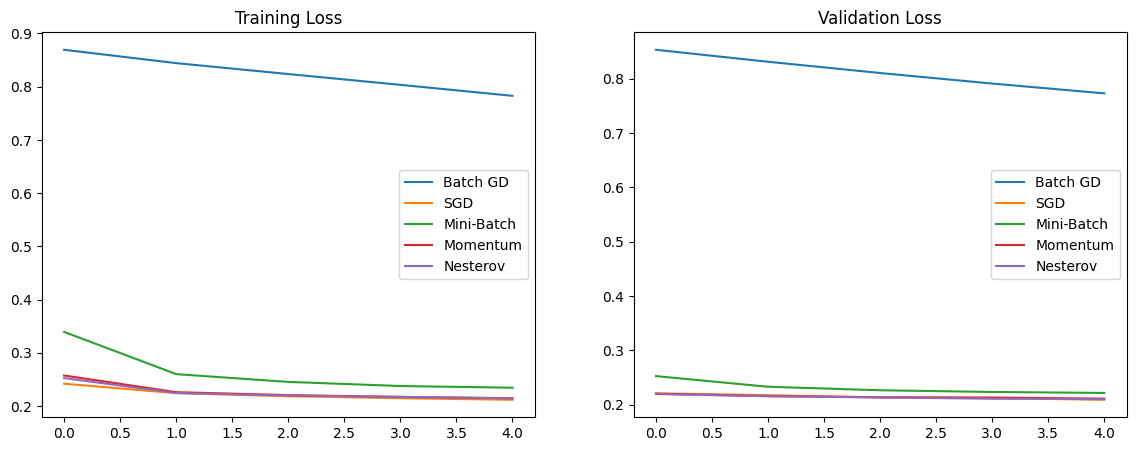

In [20]:
# Plot Loss
fig, axes = plt.subplots(1,2, figsize=(14,5))

for name, history in histories.items():
    axes[0].plot(history.history['loss'], label=name)

axes[0].set_title("Training Loss")
axes[0].legend()

for name, history in histories.items():
    axes[1].plot(history.history['val_loss'], label=name)

axes[1].set_title("Validation Loss")
axes[1].legend()

plt.show()

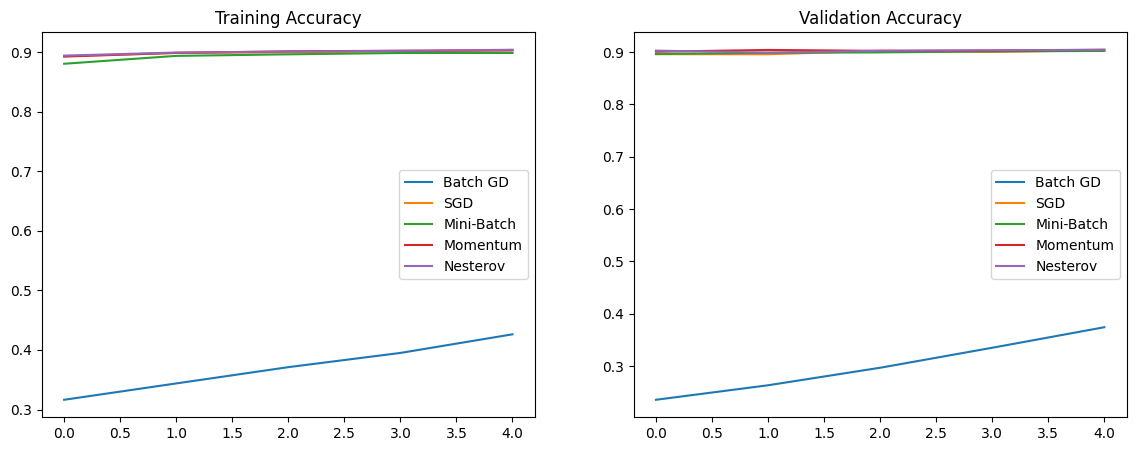

In [21]:
# Accuracy plots
fig, axes = plt.subplots(1,2, figsize=(14,5))

for name, history in histories.items():
    axes[0].plot(history.history['accuracy'], label=name)

axes[0].set_title("Training Accuracy")
axes[0].legend()

for name, history in histories.items():
    axes[1].plot(history.history['val_accuracy'], label=name)

axes[1].set_title("Validation Accuracy")
axes[1].legend()

plt.show()



In [22]:

# Select Best Optimizer
val_accuracies = {}

for name, history in histories.items():
    val_accuracies[name] = history.history['val_accuracy'][-1]

best_optimizer = max(val_accuracies, key=val_accuracies.get)
best_model = models[best_optimizer]

print("Best Optimizer:", best_optimizer)


Best Optimizer: Momentum


In [23]:
# Test Evaluation
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy: 0.8998820406959599
Precision: 0.6255506607929515
Recall: 0.35813366960907944
F1 Score: 0.45549318364073776


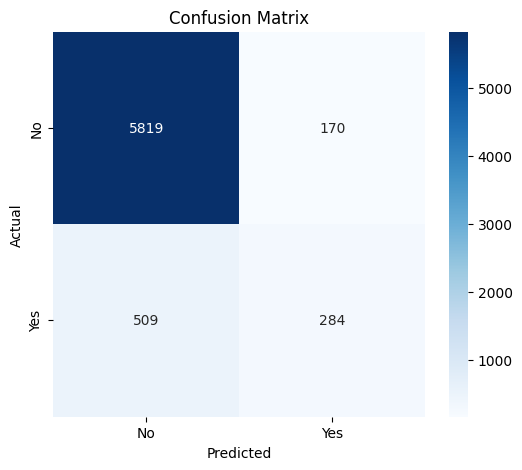

In [24]:
# Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()